## Import Libraries

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Libraries imported ✅")

Libraries imported ✅


## Load Data

In [1]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent

file_path = (
    BASE_DIR
    / "datasets"
    / "processed_datasets"
    / "clustered_data.csv"
)

df = pd.read_csv(file_path)

df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,...,Month,Is_Weekend,Season,Crime_Severity,Primary_Type_Encoded,Location_Encoded,Lat_scaled,Long_scaled,Cluster_KMeans,Cluster_DBSCAN
0,3180479,2004-02-14 04:00:00,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,RESIDENCE,False,False,331,3,5,...,2,1,Winter,5.0,5,126,-0.806220,1.643164,1,-1
1,12549744,2021-11-24 15:05:00,THEFT,RETAIL THEFT,SMALL RETAIL STORE,False,False,2032,20,47,...,11,0,Fall,2.0,31,146,1.459480,0.049758,4,-1
2,3189525,2004-02-21 18:00:00,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,1611,16,41,...,2,1,Winter,2.0,6,126,1.745940,-2.145479,0,-1
3,3371426,2004-06-08 19:00:00,THEFT,$500 AND UNDER,STREET,False,False,1211,12,2,...,6,0,Summer,2.0,31,150,0.438992,0.070117,2,-1
4,7987090,2011-03-25 09:00:00,ASSAULT,SIMPLE,RESIDENCE,False,False,2132,2,4,...,3,0,Spring,4.0,1,126,-0.470595,1.432920,1,-1


In [ ]:
# df = pd.read_csv("../datasets/processed_datasets/clustered_data.csv")

# print("Data loaded ✅")

Data loaded ✅


## Basic Check

In [24]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,...,Month,Is_Weekend,Season,Crime_Severity,Primary_Type_Encoded,Location_Encoded,Lat_scaled,Long_scaled,Cluster_KMeans,Cluster_DBSCAN
0,3180479,2004-02-14 04:00:00,CRIM SEXUAL ASSAULT,NON-AGGRAVATED,RESIDENCE,False,False,331,3,5,...,2,1,Winter,5.0,5,126,-0.806220,1.643164,1,-1
1,12549744,2021-11-24 15:05:00,THEFT,RETAIL THEFT,SMALL RETAIL STORE,False,False,2032,20,47,...,11,0,Fall,2.0,31,146,1.459480,0.049758,4,-1
2,3189525,2004-02-21 18:00:00,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,1611,16,41,...,2,1,Winter,2.0,6,126,1.745940,-2.145479,0,-1
3,3371426,2004-06-08 19:00:00,THEFT,$500 AND UNDER,STREET,False,False,1211,12,2,...,6,0,Summer,2.0,31,150,0.438992,0.070117,2,-1
4,7987090,2011-03-25 09:00:00,ASSAULT,SIMPLE,RESIDENCE,False,False,2132,2,4,...,3,0,Spring,4.0,1,126,-0.470595,1.432920,1,-1


In [25]:
df.shape

(100000, 28)

In [26]:
df.columns

Index(['ID', 'Date', 'Primary Type', 'Description', 'Location Description',
       'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area',
       'X Coordinate', 'Y Coordinate', 'Year', 'Latitude', 'Longitude', 'Hour',
       'Day_of_Week', 'Month', 'Is_Weekend', 'Season', 'Crime_Severity',
       'Primary_Type_Encoded', 'Location_Encoded', 'Lat_scaled', 'Long_scaled',
       'Cluster_KMeans', 'Cluster_DBSCAN'],
      dtype='object')

## PCA


#### Select Features

In [27]:
features = [
    "Lat_scaled",
    "Long_scaled",
    "Hour",
    "Month",
    "Is_Weekend",
    "Crime_Severity",
    "Primary_Type_Encoded",
    "Location_Encoded"
]

X_full = df[features]

X_full.head()

,Lat_scaled,Long_scaled,Hour,Month,Is_Weekend,Crime_Severity,Primary_Type_Encoded,Location_Encoded
0,-0.806220,1.643164,4,2,1,5.0,5,126
1,1.459480,0.049758,15,11,0,2.0,31,146
2,1.745940,-2.145479,18,2,1,2.0,6,126
3,0.438992,0.070117,19,6,0,2.0,31,150
4,-0.470595,1.432920,9,3,0,4.0,1,126


#### Apply PCA

In [28]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_full)

#### Explained Variance

In [29]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.9237199  0.05300188]
Total Variance: 0.976721779479492


#### Create PCA Dataframe


In [30]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

df_pca["Cluster"] = df["Cluster_KMeans"]

df_pca.head()

,PC1,PC2,Cluster
0,14.518735,-10.401415,1
1,35.364746,15.353256,4
2,14.650656,-8.975160,0
3,39.388552,15.283189,2
4,14.437296,-14.244508,1


#### PCA Visualization

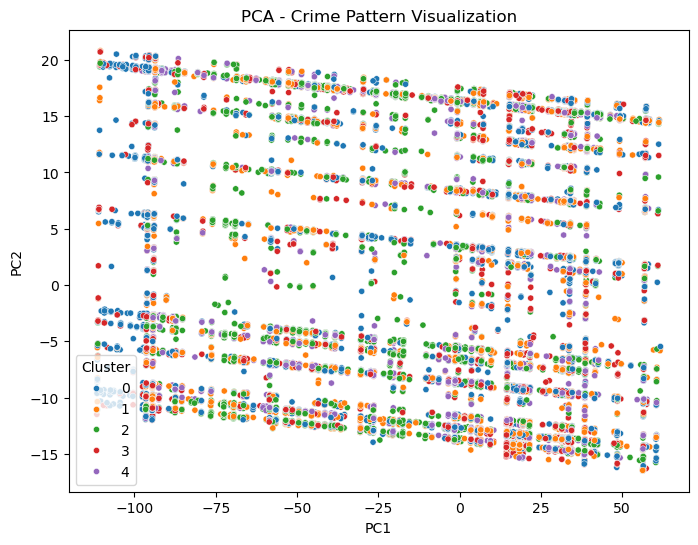

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    data=df_pca,
    s=20
)

plt.title("PCA - Crime Pattern Visualization")
plt.show()

#### Important Features

In [32]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)

loadings

,Lat_scaled,Long_scaled,Hour,Month,Is_Weekend,Crime_Severity,Primary_Type_Encoded,Location_Encoded
PC1,-0.000719,-0.000495,0.006978,0.000595,-0.000047,-0.001531,0.029591,0.999536
PC2,0.007299,-0.000177,0.018102,0.003206,-0.000930,-0.051837,0.998016,-0.029749


In [33]:
if "Lat_scaled" not in df.columns:
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    df[["Lat_scaled", "Long_scaled"]] = scaler.fit_transform(
        df[["Latitude", "Longitude"]]
    )

In [34]:
df = pd.read_csv("../datasets/processed_datasets/clustered_data.csv")

# 🔥 FIX: reset index
df = df.sample(5000, random_state=42).reset_index(drop=True)

features = [
    "Lat_scaled",
    "Long_scaled",
    "Hour",
    "Month",
    "Is_Weekend",
    "Crime_Severity",
    "Primary_Type_Encoded",
    "Location_Encoded"
]

X = df[features]

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Now indices match ✅
df_pca["Cluster"] = df["Cluster_KMeans"]

## t-SNE

#### Sample Data

In [35]:
df_sample = df.sample(5000, random_state=42).reset_index(drop=True)

X_sample = df_sample[features]

#### Apply t-SNE

In [36]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_sample)

In [37]:
print("t-SNE shape:", X_tsne.shape)

t-SNE shape: (5000, 2)


#### Create t-SNE Dataframe

In [38]:
df_tsne = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])

df_tsne["Cluster"] = df_sample["Cluster_KMeans"]

#### Visualization

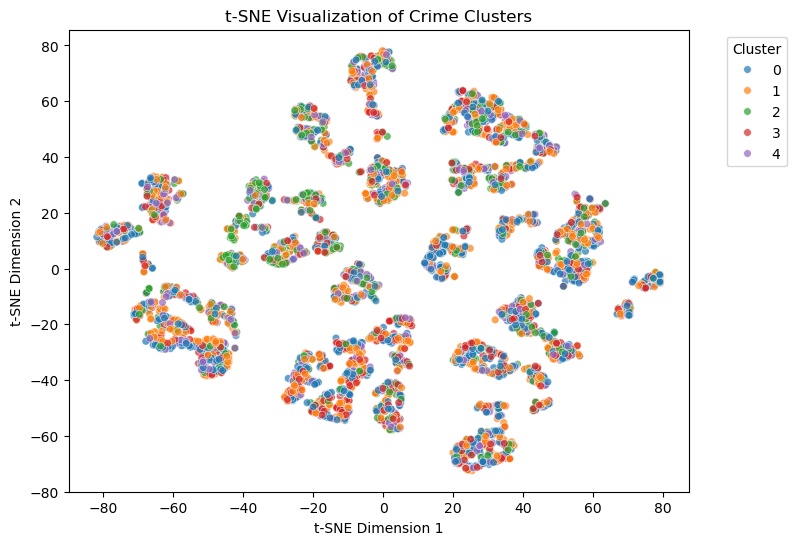

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Dim1",
    y="Dim2",
    hue="Cluster",
    palette="tab10",
    data=df_tsne,
    s=30,              # slightly bigger
    alpha=0.7          # smoother look
)

plt.title("t-SNE Visualization of Crime Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### t-SNE Interpretation

t-SNE reduces high-dimensional crime data into 2D space while preserving local relationships.

The visualization shows that clusters formed using KMeans exhibit meaningful grouping patterns, confirming the presence of distinct crime behavior regions.

## UMAP 

Note: you may need to restart the kernel to use updated packages.


d:\anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


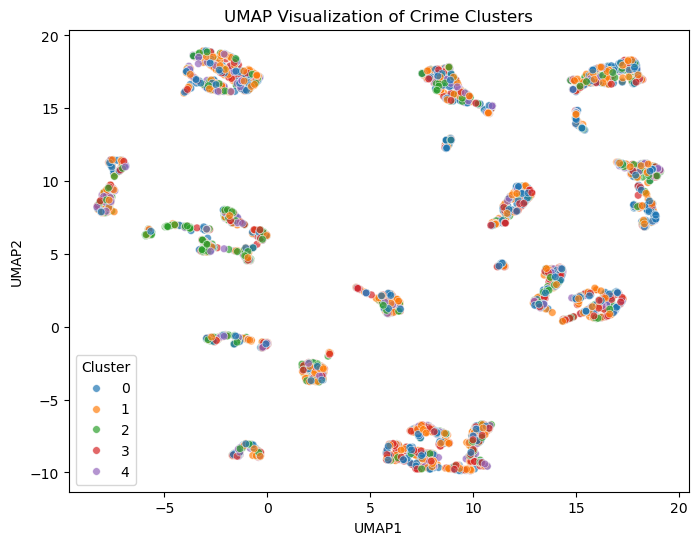

In [40]:
%pip install umap-learn

from umap import UMAP

# Same sample and features
X_sample = df_sample[features]

# UMAP
umap_model = UMAP(n_components=2, random_state=42)

X_umap = umap_model.fit_transform(X_sample)

# Dataframe
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["Cluster"] = df_sample["Cluster_KMeans"]

# Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="tab10",
    data=df_umap,
    s=30,
    alpha=0.7
)

plt.title("UMAP Visualization of Crime Clusters")

plt.show()

### UMAP Interpretation

UMAP preserves both local and global structure of the data and is computationally efficient.

Compared to t-SNE, UMAP provides clearer separation of clusters and faster computation, making it suitable for large datasets.

### Dimensionality Reduction Summary

PCA reduced the dataset to 2 components while retaining significant variance. 
It helped identify key features influencing crime patterns such as location and time.

t-SNE provided a more visually distinct separation of clusters, making it useful 
for understanding hidden structures in crime data.

These techniques improve interpretability and support clustering results.